# Constructing Parity Phase Gates

The parity phase gate, generated by a multi-qubit $Z$ interaction, can be written as

$$
U_n(\theta) = e^{-i \gamma Z_1 Z_2 \cdots Z_n},
$$

where $\gamma$ denotes the target phase.

We express this operation in terms of the following primitive gates:

- single-qubit $Z$ rotations, $R_Z(\phi) = e^{-i \frac{\phi}{2} Z}$, and  
- $k$-qubit controlled-phase gates ($k \ge 2$) acting on a subset $S = \{i_1,\dots,i_k\}$,
  $$
  \mathrm{CP}^{(k)}_S(\phi)=\exp\!\left(i \phi \, |1\cdots1\rangle\langle 1\cdots1|_S\right).
  $$
This formulation enables the use of built-in tools in RydOpt to design optimal pulse sequences for implementing the parity gate.

The construction is based on expressing Pauli-$Z$ operators in terms of projectors onto the computational basis state $|1\rangle$. Using

$$
|1\rangle\langle 1| = \frac{1}{2}(I - Z),
$$

A Pauli-$Z$ string can be written as

$$
Z_1 Z_2 \cdots Z_n=\prod_{i=1}^{n} (I - 2 P_i),\qquad P_i = |1\rangle\langle 1|_i.
$$

Expanding this product yields

$$
Z_1 \cdots Z_n=\sum_{k=0}^{n}(-1)^k 2^k
\sum_{\substack{S \subseteq \{1,\dots,n\} \\ |S| = k}}P_S,\qquad P_S = |1\cdots1\rangle\langle1\cdots1|_S,
$$

which, upon exponentiation, decomposes into a product of commuting phase gates: single-qubit $R_Z$ rotations from the $k=1$ terms and $k$-qubit controlled-phase gates for $k \ge 2$.

For a general $n$-qubit parity operator, the resulting decomposition is

$$
\begin{aligned}
U_n(\theta)
&=
\prod_{i=1}^{n} R_Z^{(i)}(-2\gamma)
\\
&\quad\times
\prod_{k=2}^{n}
\prod_{\substack{S \subseteq \{1,\dots,n\} \\ |S| = k}}
\mathrm{CP}^{(k)}_S\!\left(
(-1)^k 2^k \gamma
\right).
\end{aligned}
$$

As a concrete example, for $n=3$,

$$
\begin{aligned}
e^{-i \gamma Z_1 Z_2 Z_3}
&=
R_Z^{(1)}(-2\gamma)\,
R_Z^{(2)}(-2\gamma)\,
R_Z^{(3)}(-2\gamma)
\\
&\quad\times
\mathrm{CP}_{12}(4\gamma)\,
\mathrm{CP}_{13}(4\gamma)\,
\mathrm{CP}_{23}(4\gamma)
\\
&\quad\times
\mathrm{CP}_{123}(-8\gamma).
\end{aligned}
$$

The coefficients ($-2, 4, -8, \dots$) arise from the powers of two in the projector expansion and exhibit an alternating sign structure.
Interestingly, at the special value $\gamma=\pi/4$, corresponding to the maximally entangling parity phase gate, all controlled-phase gates acting on three or more qubits acquire phases that are integer multiples of $2\pi$ and thus reduce to identities. As a result, $U_n(\pi/4)$ can be realized entirely using single-qubit $R_Z$ gates and two-qubit $\mathrm{CP}(\pi)=\mathrm{CZ}$ gates. In contrast, any deviation from $\gamma=\pi/4$ necessarily reintroduces genuine many-body controlled-phase interactions.

## Fixed–Target-Phase Optimization of the Parity Gate

We seek the shortest-duration pulse that implements a three-atom parity gate in the strong Rydberg blockade regime, using a fixed set of 10 pulse parameters. To this end, we carry out multiple random initializations of the pulse parameters, optimize each candidate pulse, and select the fastest one that achieves a gate fidelity exceeding the target threshold.

First, we create the target gate object. The Rydberg decay strength is set to $10^{-4}$, and we assume uniform interaction strengths between atoms, $V_{nn} = V_{nnn} = 32$.

In [1]:
# %pip install -q --progress-bar off rydopt # Uncomment for installation on Colab

import rydopt as ro
import numpy as np

phase = np.pi / 4
gate = ro.gates.ThreeQubitGateIsosceles(
    phi=None,
    theta=4 * phase,
    theta_prime=4 * phase,
    lamb=-8 * phase,
    Vnn=32,
    Vnnn=32,
    decay=0.0001,
)

Next, we create the pulse ansatz and specify upper and lower bounds for the random initialization of pulse parameters.

In [2]:
# Pulse ansatz: constant detuning, sweep of the laser phase according to sin_crab ansatz
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
)

# Bounds for the initial pulse parameter guesses
n_params = 10
min_initial_params = (15, [-1], -2 * np.ones(n_params), [1.0])
max_initial_params = (20, [1], 2 * np.ones(n_params), [1.0])

Perform 800 random parameter initializations, running in parallel on 4 CPU cores.

In [3]:
opt_result = ro.optimization.multi_start_optimize(
    gate,
    pulse_ansatz,
    min_initial_params,
    max_initial_params,
    tol=1e-6,
    num_initializations=800,
    num_steps=100,
    num_processes=4,
    return_history=True,
)

Started optimization using 4 processes



proc03:   0%|                                           | 0/100 [00:00<?, ?it/s]

proc01:   0%|                                           | 0/100 [00:00<?, ?it/s]

proc02:   0%|                                           | 0/100 [00:00<?, ?it/s]

proc00:   0%|                                           | 0/100 [00:00<?, ?it/s]


=== Optimization finished using multi-start Adam ===

Runtime: 268.305 seconds
Gates with infidelity below tol=1.0e-06: 0

Best gate:
> infidelity = 6.522358e-04
> parameters = (17.058103593612273, [0.36340936], [-1.6322714  -0.07497258 -0.50459226  0.9379905  -1.314722   -0.57308878
  2.94556097  0.16726395 -0.32945426  0.30462567], [1.])
> duration = 17.058103593612273


We plot the history of all optimization runs;

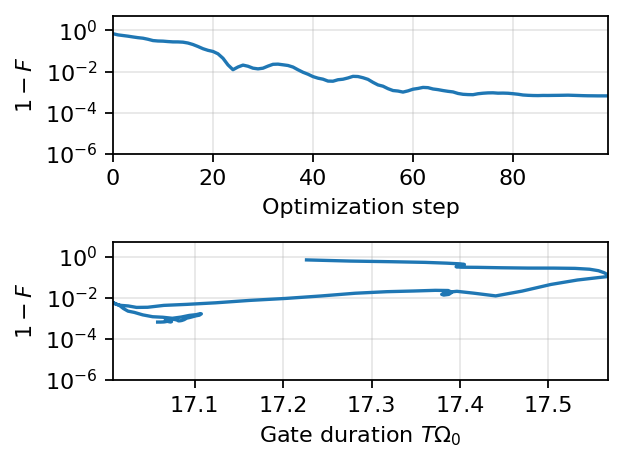

In [4]:
ro.characterization.plot_optimization_history(opt_result);

Also, we analyze the best performing gate;

In [5]:
optimized_params = opt_result.params
infidelity, infidelity_nodecay, ryd_time = ro.characterization.analyze_gate(
    gate, pulse_ansatz, optimized_params, tol=1e-10
)

print(f"Gate infidelity:             {infidelity:.4e}")
print(f"Gate infidelity (no decay):  {infidelity_nodecay:.4e}")
print(f"Rydberg time:                {ryd_time:.4f}")

Gate infidelity:             6.5229e-04
Gate infidelity (no decay):  8.2195e-06
Rydberg time:                6.4431


Finally, we plot the optimal pulse and its spectrum.

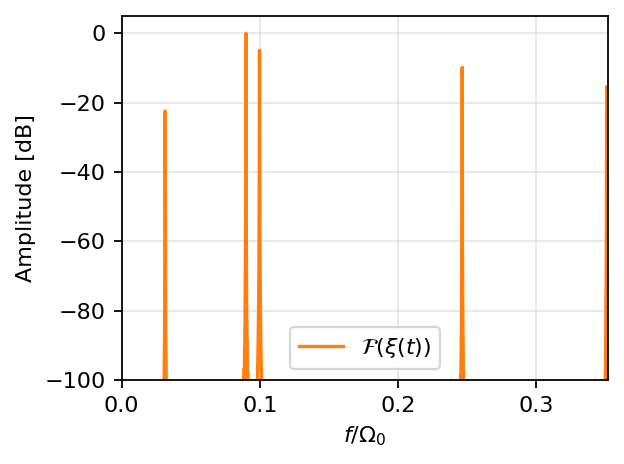

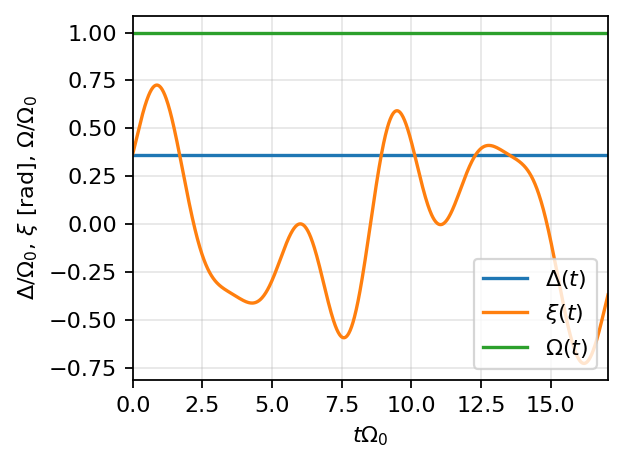

In [6]:
ro.characterization.plot_spectrum(pulse_ansatz, optimized_params)
fig, ax = ro.characterization.plot_pulse(pulse_ansatz, optimized_params)

## Parametrization of Parity Gates in the Target Phase

Here, we aim to optimize the parity gate over a range of target gate phases. To this end, we express the trainable parameters of the laser phase ansatz as polynomial functions of $\theta=4\gamma$. We begin by defining a family of parity gates with different target phases and subsequently redefine the pulse using a polynomial parameter map. Duration and other pulse parameters can be treated analogously by assigning them nonzero polynomial degrees.

In [7]:
phases = np.linspace(0.1, 0.25, 4) * np.pi

gates = [
    ro.gates.ThreeQubitGateIsosceles(
        phi=None,
        theta=4 * phase,
        theta_prime=4 * phase,
        lamb=-8 * phase,
        Vnn=32,
        Vnnn=32,
        decay=1e-4,
    )
    for phase in phases
]

gate_family = ro.gates.ParametrizedGate(
    gates=gates,
    interpolation_params=phases,
    reduction_operation="mean",
)


# --------------------------------------------------
# Pulse ansatz (CRAB + polynomial mapping)
# --------------------------------------------------
degrees = [3, 0, 3, 0]
num_params = [1, 1, n_params, 1]

pulse_mal = ro.pulses.PolynomialPulseMap(degrees=degrees, num_params=num_params)
pulse = ro.pulses.MappedPulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    pulse_map=pulse_mal,
)

With all components in place, we proceed to the optimization stage. We then assess the individual properties of each gate in the resulting family and visualize the corresponding optimal pulses.

Started optimization using 4 processes



proc03:   0%|                                           | 0/200 [00:00<?, ?it/s]

proc02:   0%|                                           | 0/200 [00:00<?, ?it/s]

proc01:   0%|                                           | 0/200 [00:00<?, ?it/s]

proc00:   0%|                                           | 0/200 [00:00<?, ?it/s]


=== Optimization finished using multi-start Adam ===

Runtime: 2259.664 seconds
Gates with infidelity below tol=1.0e-06: 0

Best gate:
> infidelity = 2.350371e-03
> parameters = ([13.58642443 26.7842968  31.17470102 10.86861758], [0.35695307], [ 0.98128241 -1.29512323 -4.90276642 -5.06808479  2.1399617  -2.37433484
 -4.6598816  -5.04324352 -1.01650344  2.77715409  2.29273945  3.4548681
 -0.61837545 -2.2265599  -4.20084627 -4.50778332  0.32383472  0.28415251
 -1.82355667 -2.30623185 -1.10479831  1.87433511 -0.3074172   0.80454406
 -0.60929517  0.707301   -0.00964304  2.14280859  0.81970462  0.54863252
  0.57674536  1.36461612  0.41554974  3.02310632  6.66955041  6.21694235
  0.40956425 -1.23411977 -0.19724339 -1.25957609], [])
> duration = [13.58642443 26.7842968  31.17470102 10.86861758]

=== Performance analysis of the best/fastest optimized gate pulse ===

Target phase:                0.10
Gate infidelity:             1.4256e-03
Gate infidelity (no decay):  6.9548e-04
Rydberg time: 

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$t \\Omega_0$', ylabel='$\\xi$ [rad]'>)

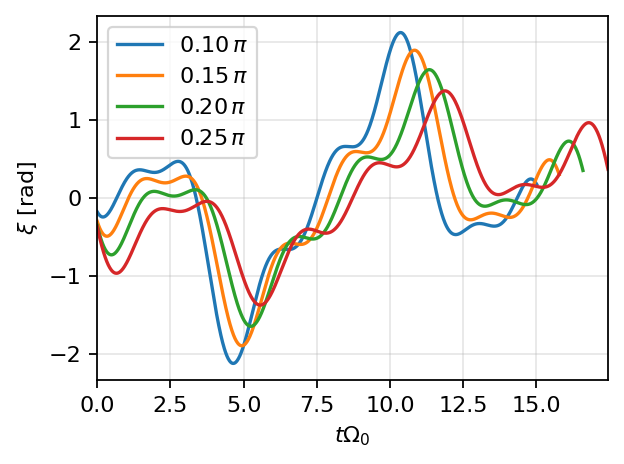

In [8]:
min_initial_params = (
    [0.0, *[0.0] * degrees[0]],
    [-1.0],
    -2 * np.ones((n_params, degrees[2] + 1)),
    [],
)

max_initial_params = (
    [10.0, *[34.0] * degrees[0]],
    [1.0],
    2 * np.ones((n_params, degrees[2] + 1)),
    [],
)

opt_result_gate_family = ro.optimization.multi_start_optimize(
    gate_family,
    pulse,
    min_initial_params,
    max_initial_params,
    tol=1e-6,
    num_initializations=1000,
    num_steps=200,
    num_processes=4,
    return_history=False,
)

optimized_params_gate_family = opt_result_gate_family.params

print("\n=== Performance analysis of the best/fastest optimized gate pulse ===\n")
for gate in gate_family.gates:
    infidelity, infidelity_nodecay, ryd_time = ro.characterization.analyze_gate(
        gate, pulse, optimized_params_gate_family, tol=1e-6
    )

    # Print the gate performance measures
    print(f"Target phase:                {pulse.target_phase(gate) * 2:.2f}")
    print(f"Gate infidelity:             {infidelity:.4e}")
    print(f"Gate infidelity (no decay):  {infidelity_nodecay:.4e}")
    print(f"Rydberg time:                {ryd_time:.4f}\n")

ro.characterization.plot_mapped_pulse(
    pulse, optimized_params_gate_family, gate_family, plot_detuning=False, plot_rabi=False
)